In [1]:
from AutoEncoder_Experiment import *
import sys, jax, json
import jax.numpy as jnp
from datetime import datetime

import jax_amber3 as ja
import training_functions as tf

jax.config.update("jax_enable_x64", True)

In [2]:
json_fn = 'DA_A.1.json'
with open(json_fn, 'r') as g:
        json_params = json.load(g)

In [ ]:
experiment = AutoEncoder_Experiment(json_fn, run_main=True)

(2400, 306) (600, 306)
### MODEL TYPE = AE_Sigmoid_Dropout ###
######################################
#####     Initializing Done!     #####
Sigmoid_Dropout_AutoEncoder(
    # attributes
    input_size = 306
    hidden_layers = [300, 300, 200, 100, 50]
    n_latents = 7
    dropout_rates = [0.1, 0.3, 0.2, 0, 0]
)
######################################
epoch 0 atom_rmsd_nm 1.1750E+00 1.1750E+00 torsional 9.9505E-01 9.9488E-01 dPotEnr 3.1871E+10 3.1776E+10 Summation 3.0690E+01 3.0689E+01 B=1.0000E+00 L=0.0000E+00
epoch 1 atom_rmsd_nm 1.1500E+00 1.1501E+00 torsional 9.7844E-01 9.7823E-01 dPotEnr 8.2488E+14 8.2258E+14 Summation 3.0103E+01 3.0101E+01 B=1.0000E+00 L=0.0000E+00
epoch 2 atom_rmsd_nm 1.1244E+00 1.1245E+00 torsional 9.6478E-01 9.6450E-01 dPotEnr 1.3334E+16 1.3298E+16 Summation 2.9548E+01 2.9546E+01 B=1.0000E+00 L=0.0000E+00
epoch 3 atom_rmsd_nm 1.0988E+00 1.0989E+00 torsional 9.5243E-01 9.5216E-01 dPotEnr 2.7545E+12 2.7508E+12 Summation 2.9011E+01 2.9009E+01 B=1.0000E+00 L=0.000

In [9]:
rng_init = jax.random.PRNGKey(54)
rng, key = jax.random.split(rng_init)
recon, latents = experiment.state.apply_fn({'params':experiment.state.params}, experiment.test_data, rng)

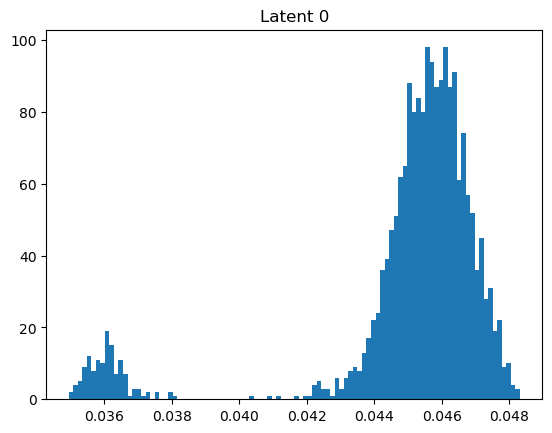

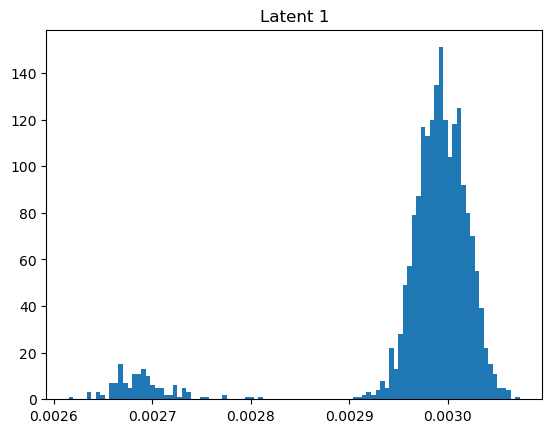

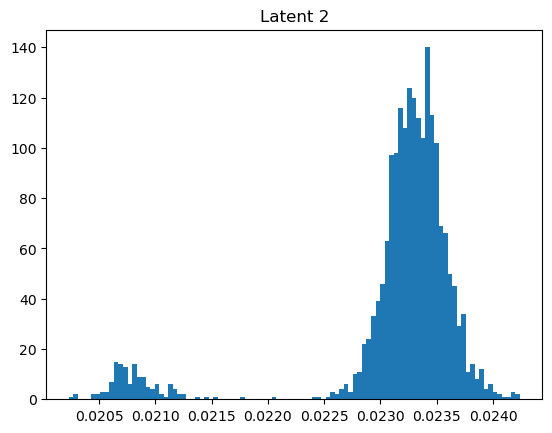

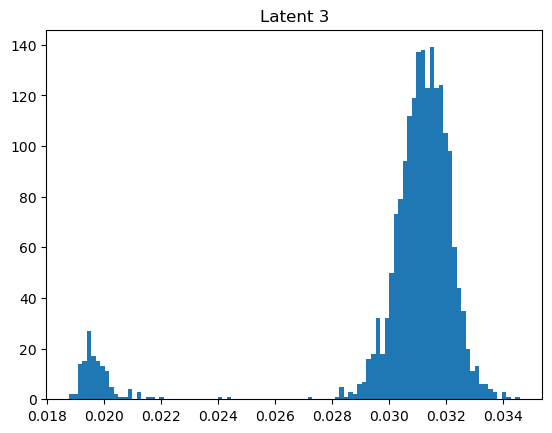

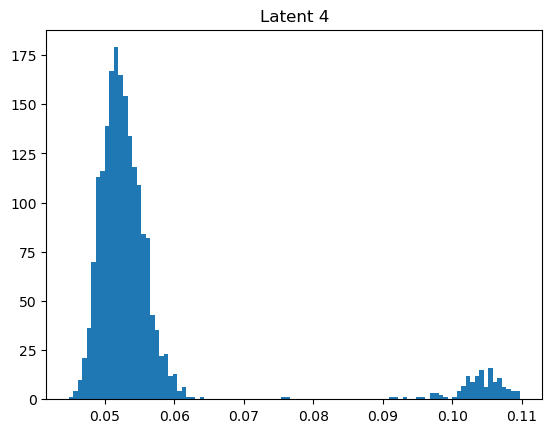

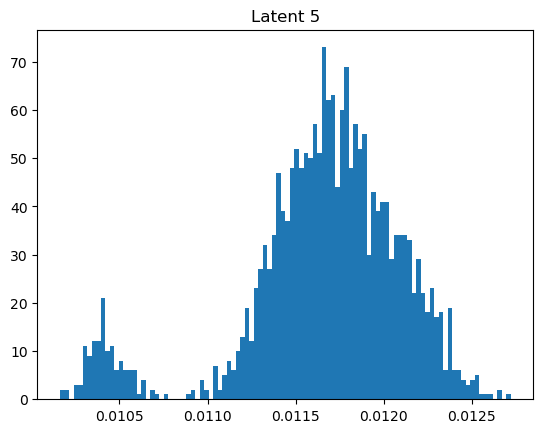

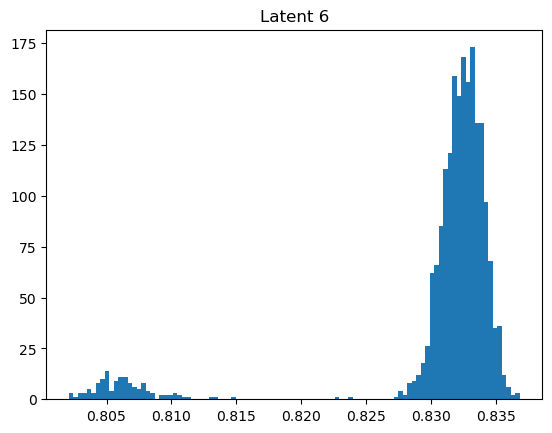

In [10]:
for i in range(latents.shape[-1]):
    plt.clf()
    plt.title(f'Latent {i}')
    _ = plt.hist(latents[:, i], bins=100)
    plt.show()

In [11]:
from sklearn.mixture import GaussianMixture

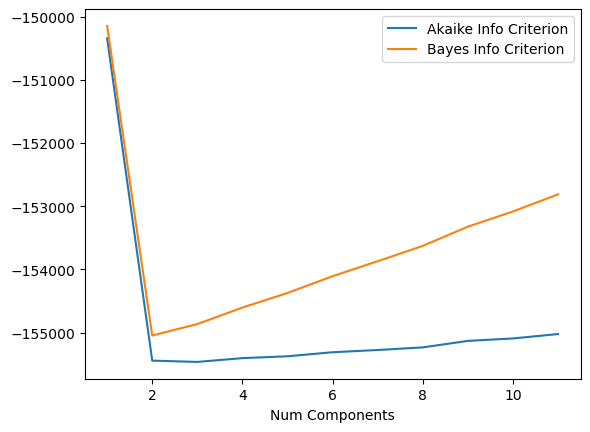

In [13]:
ics = []
for i in range(1, 12):
    X = np.array(latents)
    MM = GaussianMixture(n_components=i).fit(X)
    ics.append((i, MM.aic(X), MM.bic(X)))
ics = np.array(ics)
plt.clf()
_ = plt.plot(ics[:, 0], ics[:, 1])
_ = plt.plot(ics[:, 0], ics[:, 2])
plt.legend(('Akaike Info Criterion', 'Bayes Info Criterion'))
plt.xlabel('Num Components')
plt.show()

In [14]:
X = np.array(latents)
MM = GaussianMixture(n_components=2).fit(X) #chosen based on above graph
samples = MM.sample(1800)[0]

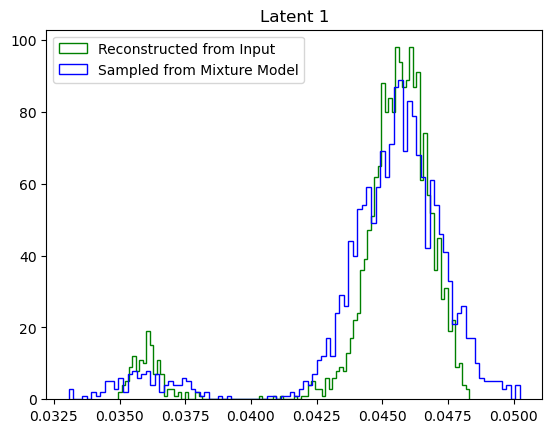

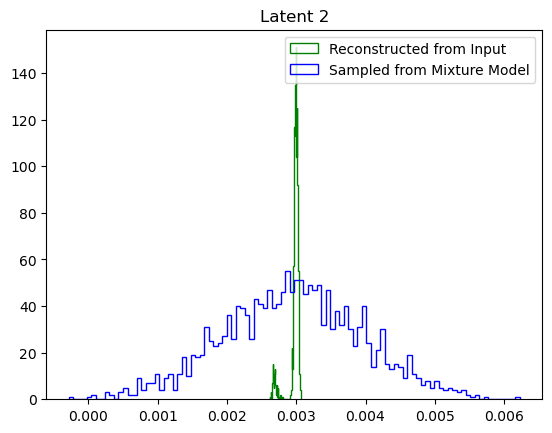

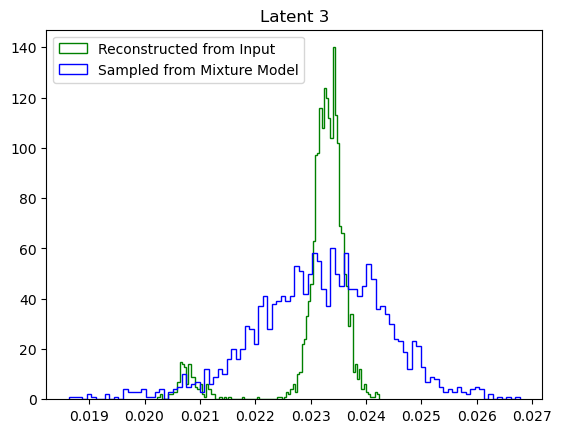

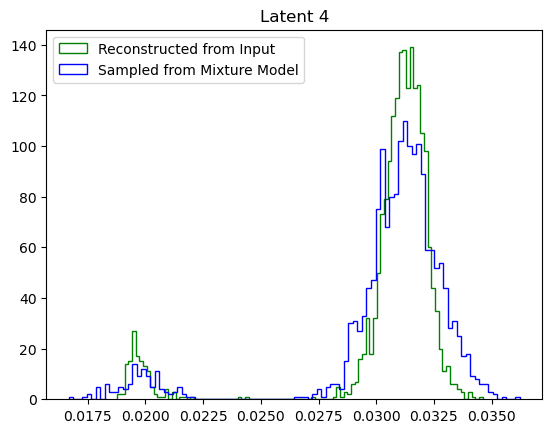

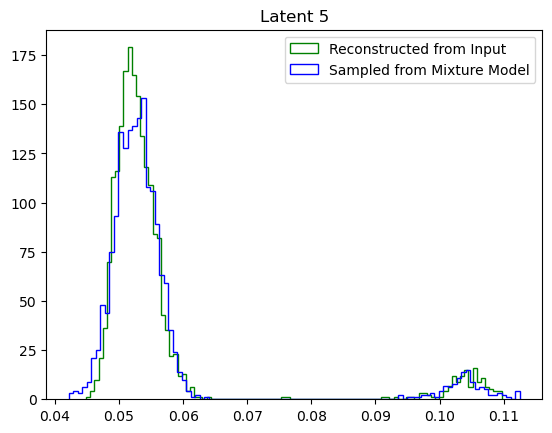

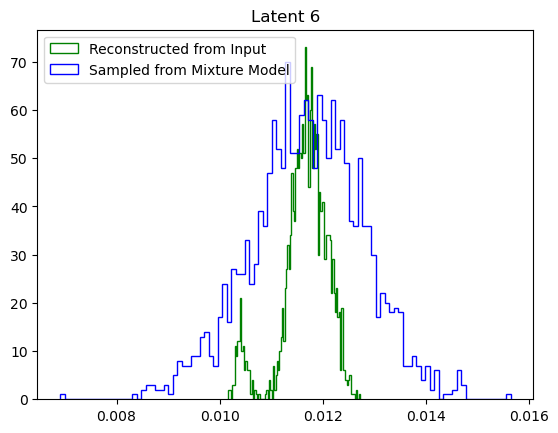

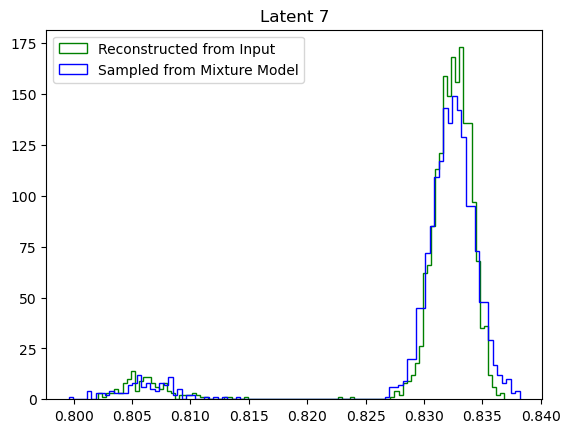

In [15]:
for i in range(samples.shape[-1]):
    plt.clf()
    _ = plt.hist(latents[:,i], bins=100, histtype='step', color='g')
    _ = plt.hist(samples[:,i], bins=100, histtype='step', color='b')
    plt.legend(('Reconstructed from Input', 'Sampled from Mixture Model'))
    plt.title(f'Latent {i+1}')
    plt.show()

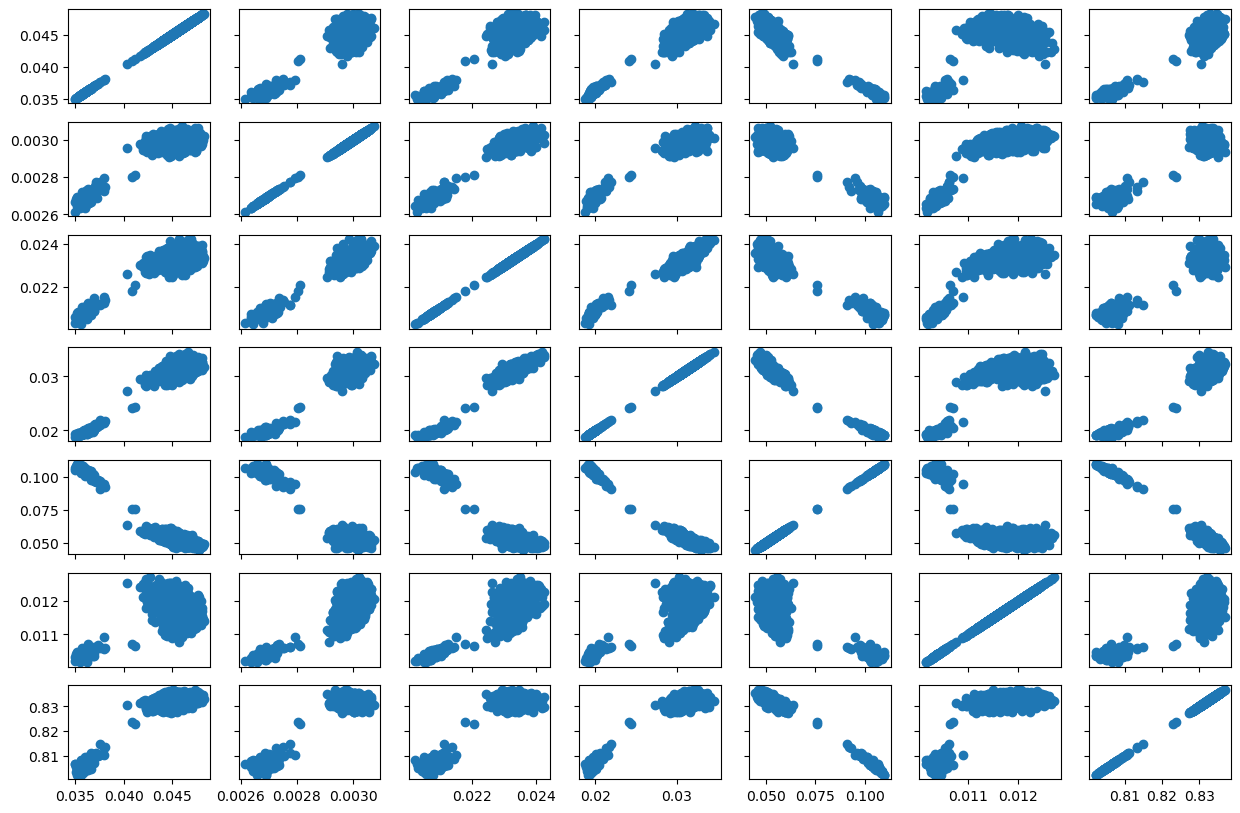

In [16]:
n_L = latents.shape[-1]
fig, axs = plt.subplots(n_L, n_L, figsize=(15, 10), sharex='col', sharey='row')
for i in range(n_L):
    for j in range(n_L):
        axs[i,j].scatter(latents[:,j], latents[:,i])
fig.savefig('7L.png', dpi=600)

In [20]:
import jax_amber3 as ja
gas_fun, tors_fun = ja.get_amber_functions('Simulation/ala_deca_peptide.prmtop')

Excluding Outliers GMM - 1800 RECON - 2000


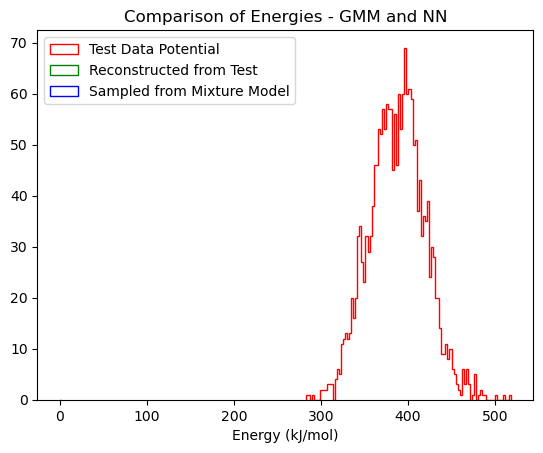

In [21]:
plt.clf()

recon_energies = gas_fun(recon)

decoded_samples = experiment.model.apply({'params': experiment.state.params}, samples, rng, method=experiment.model.decode)
sampled_energies = gas_fun(decoded_samples)

org_energies = gas_fun(experiment.test_data)

threshold = 1e3
num_excluded_gmm = len(sampled_energies) - len(sampled_energies[sampled_energies<threshold])
num_excluded_nn  = len(recon_energies) - len(recon_energies[recon_energies<threshold])
print(f'Excluding Outliers GMM - {num_excluded_gmm} RECON - {num_excluded_nn}')

_ = plt.hist(org_energies[org_energies < threshold], bins=100, histtype='step', color='r')
_ = plt.hist(recon_energies[recon_energies<threshold], bins=100, histtype='step', color='g')
_ = plt.hist(sampled_energies[sampled_energies<threshold], bins=100, histtype='step', color='b')

plt.legend(('Test Data Potential', 'Reconstructed from Test', 'Sampled from Mixture Model'))
plt.xlabel('Energy (kJ/mol)')
plt.title('Comparison of Energies - GMM and NN')
plt.show()

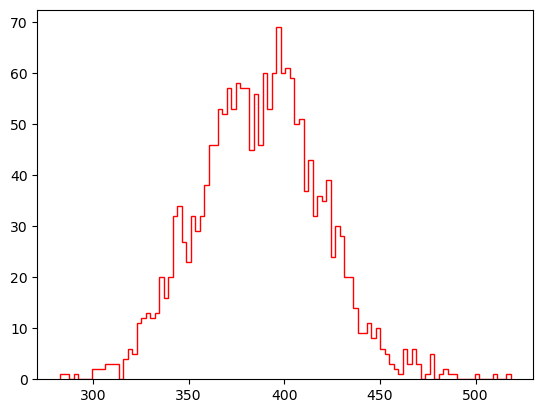

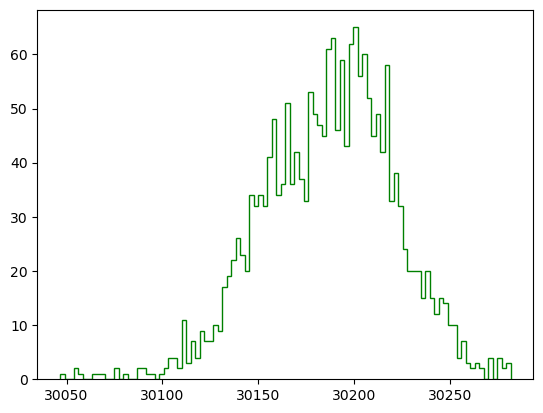

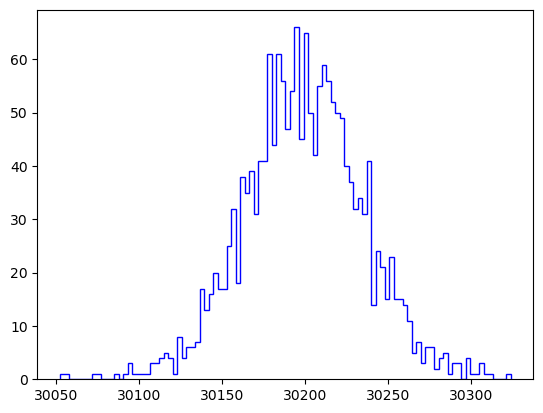

In [22]:
plt.clf()
_ = plt.hist(org_energies, bins=100, histtype='step', color='r')
plt.show()
plt.clf()
_ = plt.hist(recon_energies, bins=100, histtype='step', color='g')
plt.show()
plt.clf()
_ = plt.hist(sampled_energies, bins=100, histtype='step', color='b')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [47]:
import math
def cosine_taylor_expansion(xs, num_terms):
    nth_term = lambda n, x: ((-1)**n)*((x)**(2*n))/(math.factorial(2*n))
    result = jnp.zeros(xs.shape)
    for i in range(0, num_terms):
        result += nth_term(i, xs)
    return result

def taylor_torsional_dist(xs):
    return jnp.sqrt(2*(1-cosine_taylor_expansion(xs, 10)))

In [52]:
xs = jnp.linspace(-0.0003 * jnp.pi, 0.0003*jnp.pi, 100)

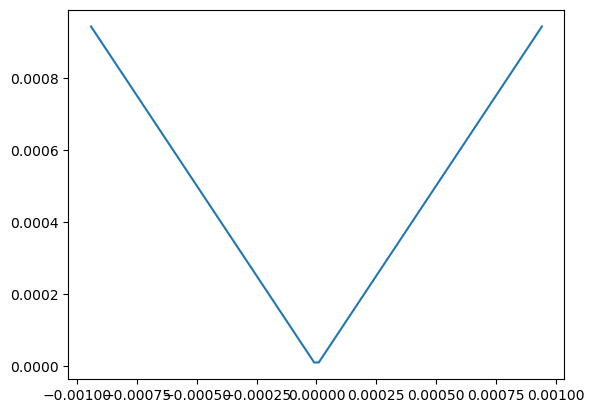

In [53]:
plt.clf()
ys_cos = jnp.cos(xs)
taylor_exp = taylor_torsional_dist(xs)
plt.plot(xs, taylor_exp)

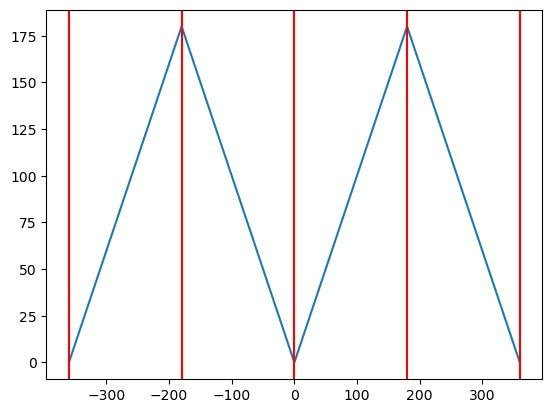

In [21]:
xs = jnp.linspace(-2 * 180, 2*180, 10000)
y_fun = lambda xs: 180 - jnp.abs(jnp.abs(xs) - 180)
ys = y_fun(xs)
import matplotlib.pyplot as plt
plt.clf()
_ = plt.plot(xs, ys)
for i in [-360, -180, 0, 180, 360]:
    plt.axvline(i, color='r')
plt.show()